In [78]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import qilisdk as ql



In [79]:
import numpy as np
from qilisdk.analog import Schedule, X, Z, Y
from qilisdk.core import QTensor, tensor_prod, basis_state
from qilisdk.core.interpolator import Interpolation
from qilisdk.backends import QiliSim, CudaBackend
from qilisdk.functionals import AnalogEvolution
from qilisdk.readout import Readout



# Define total time and timestep
T = 10.0
dt = 0.5
nqubits = 1

# Define Hamiltonians
Hx = -sum(X(i) for i in range(nqubits))
Hz = sum(Z(i) for i in range(nqubits))

# Create the AnalogEvolution functional
analog_evolution = AnalogEvolution(
    schedule=Schedule.linear(Hx, Hz, total_time=T, dt=dt),
    initial_state=QTensor.uniform(nqubits),
    store_intermediate_results=False,
)

# Execute on QiliSim backend and inspect results
backend = QiliSim()
results = backend.execute(
    analog_evolution,
    Readout().with_expectation(observables=[Z(0), X(0), Y(0)]),
)
print(results)

- Functional Results: [

Expectation Value Results: (
	expectation_values=[-0.9945624206225244, -0.031014579984750854, -0.09941673558226609],
)

]


# Build Hamiltonian

## Standard F-H

In [170]:
chain_length = 5 # up: 0,1,2,3 down: 4,5,6,7
nqubits = chain_length*2
target_qubit = 3 

t = 1
U = 1
e = 1

Hz         = sum((-e/2 + U/4)*Z(i) for i in range(nqubits))                       # from 0 to 7
H_hop_up   = sum(t*X(i)*X(i+1)+Y(i)*Y(i+1) for i in range(chain_length-1))          # 0-1, 1-2, 2-3
H_hop_down = sum(t*X(i)*X(i+1)+Y(i)*Y(i+1) for i in range(chain_length, nqubits-1)) # 4-5, 5-6, 6-7
H_int      = sum(U/4*Z(i)*Z(chain_length +i) for i in range(chain_length))            # 0-4, 1-5, 2-6, 3-7

H_tot = Hz + H_hop_up + H_hop_down + H_int


In [ ]:
T = 2.0
dt = 0.01

single_qubit_states = [basis_state(0, 2)]*(2) + [basis_state(1, 2)] + [basis_state(0, 2)]*(2) + [basis_state(0, 2)]*(2) + [basis_state(1, 2)] + [basis_state(0, 2)]*(2)

# Create the AnalogEvolution functional
analog_evolution = AnalogEvolution(
    schedule=Schedule.linear(H_tot, H_tot, total_time=T, dt=dt),
    initial_state=tensor_prod(single_qubit_states),
    store_intermediate_results=True,
)

# Execute on QiliSim backend and inspect results
backend = QiliSim()
results = backend.execute(
    analog_evolution,
    Readout().with_expectation(observables=[Z(i) for i in range(nqubits)]),
)


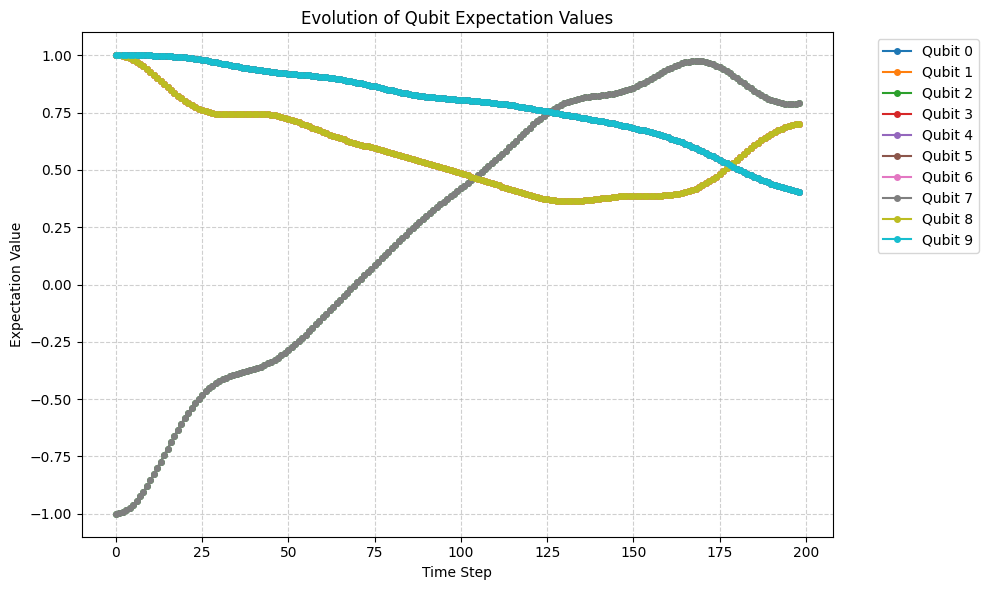

In [ ]:

expectation_values = results.get_intermediate_expectation_values()

# 2. Convert to a NumPy array for easy slicing
# This creates a shape (20, 8)
data_array = np.array(expectation_values)

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Number of qubits is the size of the second dimension (8)
n_qubits = data_array.shape[1]
# Number of time steps (20)
time_steps = np.arange(data_array.shape[0])

# 4. Plot each qubit as its own line
for i in range(n_qubits):
    plt.plot(time_steps, data_array[:, i], label=f'Qubit {i}', marker='o', markersize=4)

# Formatting the plot
plt.title('Evolution of Qubit Expectation Values')
plt.xlabel('Time Step')
plt.ylabel('Expectation Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Puts legend outside
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()